<a href="https://colab.research.google.com/github/GUIVICFISHER/RiskNeutralKernel2026/blob/main/PYTHON_STOCK_DATA_GEN_SIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

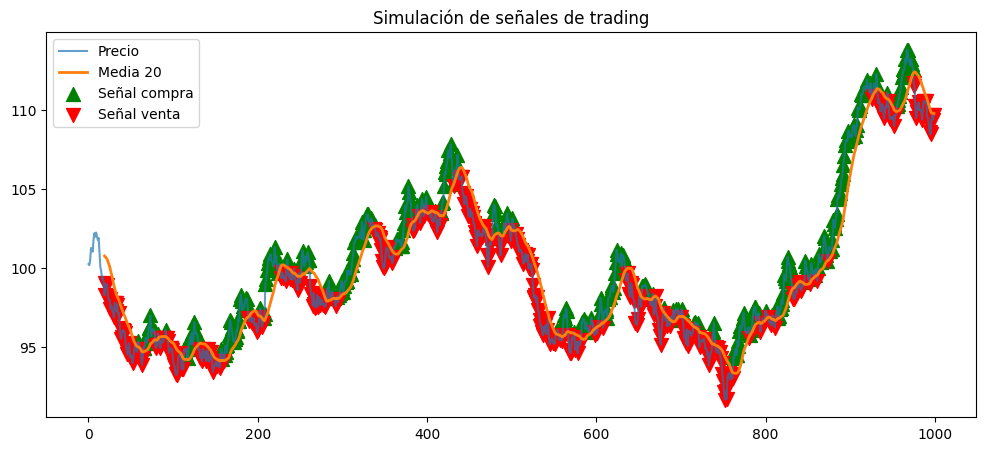

Primeras filas del DataFrame df_simulacion creado:


,Precio,Media_Movil,Señal_Compra,Señal_Venta
19,98.287014,100.755947,False,True
20,99.019839,100.694521,False,True
21,98.906951,100.630907,False,True
22,98.940715,100.552789,False,True
23,98.228341,100.400977,False,True


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Importar pandas aquí

# Para que las gráficas se muestren dentro del cuaderno
%matplotlib inline

# Simular precio con random walk
np.random.seed(42)
pasos = 1000
precio = 100 + np.cumsum(np.random.randn(pasos) * 0.5)

# Calcular media móvil simple
ventana = 20
media_movil = np.convolve(precio, np.ones(ventana)/ventana, mode='valid')

# Generar señales
precio_recortado = precio[ventana-1:]
senal_compra = precio_recortado > media_movil
senal_venta = precio_recortado < media_movil

# Crear un DataFrame con los datos simulados aquí para que esté disponible globalmente
df_simulacion = pd.DataFrame({
    'Precio': precio_recortado,
    'Media_Movil': media_movil,
    'Señal_Compra': senal_compra,
    'Señal_Venta': senal_venta
}, index=range(ventana-1, len(precio)))

# Visualizar
plt.figure(figsize=(12,5))
plt.plot(precio, label='Precio', alpha=0.7)
plt.plot(range(ventana-1, len(precio)), media_movil, label=f'Media {ventana}', linewidth=2)
plt.scatter(np.where(senal_compra)[0] + ventana-1,
            precio_recortado[senal_compra],
            color='green', marker='^', s=100, label='Señal compra')
plt.scatter(np.where(senal_venta)[0] + ventana-1,
            precio_recortado[senal_venta],
            color='red', marker='v', s=100, label='Señal venta')
plt.legend()
plt.title("Simulación de señales de trading")
plt.show()

print("Primeras filas del DataFrame df_simulacion creado:")
display(df_simulacion.head())

### Adición de Volumen Simulado

Dado que solicitaste el volumen y no estaba incluido en la simulación inicial, generaremos un volumen aleatorio para cada paso de tiempo y lo añadiremos a nuestro DataFrame `df_simulacion`.

In [5]:
import numpy as np

# Simular volumen para cada paso de tiempo en df_simulacion
np.random.seed(43) # Usar una semilla diferente para la reproducibilidad del volumen
df_simulacion['Volumen'] = np.random.randint(100, 1000, size=len(df_simulacion))

print('Primeras filas del DataFrame con volumen simulado:')
display(df_simulacion.head())

Primeras filas del DataFrame con volumen simulado:


,Precio,Media_Movil,Señal_Compra,Señal_Venta,Volumen
19,98.287014,100.755947,False,True,936
20,99.019839,100.694521,False,True,420
21,98.906951,100.630907,False,True,355
22,98.940715,100.552789,False,True,917
23,98.228341,100.400977,False,True,377


### Bandas de Bollinger (Bollinger Bands)

Las Bandas de Bollinger miden la volatilidad y los posibles niveles de sobrecompra/sobreventa. Consisten en una media móvil (banda media) y dos bandas de desviación estándar por encima y por debajo.

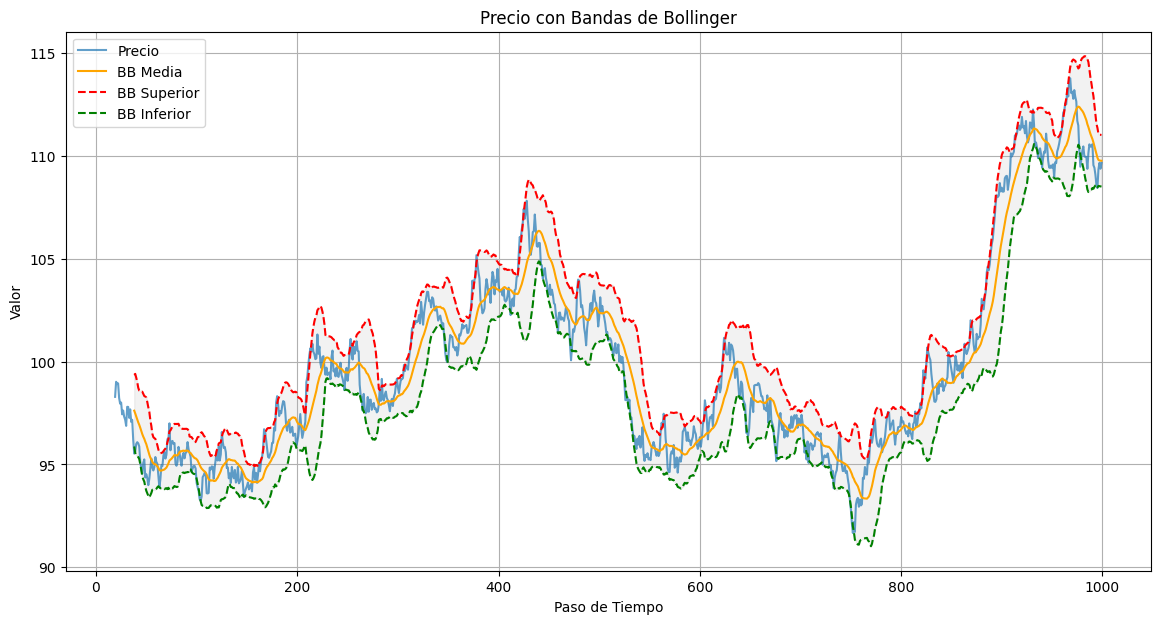

In [6]:
# Calcular Bandas de Bollinger
periodo_bb = 20 # Mismo periodo que la media móvil simple
df_simulacion['BB_Media'] = df_simulacion['Precio'].rolling(window=periodo_bb).mean()
df_simulacion['BB_StdDev'] = df_simulacion['Precio'].rolling(window=periodo_bb).std()
df_simulacion['BB_Superior'] = df_simulacion['BB_Media'] + (df_simulacion['BB_StdDev'] * 2)
df_simulacion['BB_Inferior'] = df_simulacion['BB_Media'] - (df_simulacion['BB_StdDev'] * 2)

# Visualizar Bandas de Bollinger
plt.figure(figsize=(14, 7))
plt.plot(df_simulacion.index, df_simulacion['Precio'], label='Precio', alpha=0.7)
plt.plot(df_simulacion.index, df_simulacion['BB_Media'], label='BB Media', color='orange')
plt.plot(df_simulacion.index, df_simulacion['BB_Superior'], label='BB Superior', color='red', linestyle='--')
plt.plot(df_simulacion.index, df_simulacion['BB_Inferior'], label='BB Inferior', color='green', linestyle='--')
plt.fill_between(df_simulacion.index, df_simulacion['BB_Inferior'], df_simulacion['BB_Superior'], color='grey', alpha=0.1)
plt.title('Precio con Bandas de Bollinger')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

### Índice de Fuerza Relativa (RSI - Relative Strength Index)

El RSI es un oscilador de momentum que mide la velocidad y el cambio de los movimientos de los precios. Se utiliza para identificar condiciones de sobrecompra (generalmente > 70) y sobreventa (generalmente < 30).

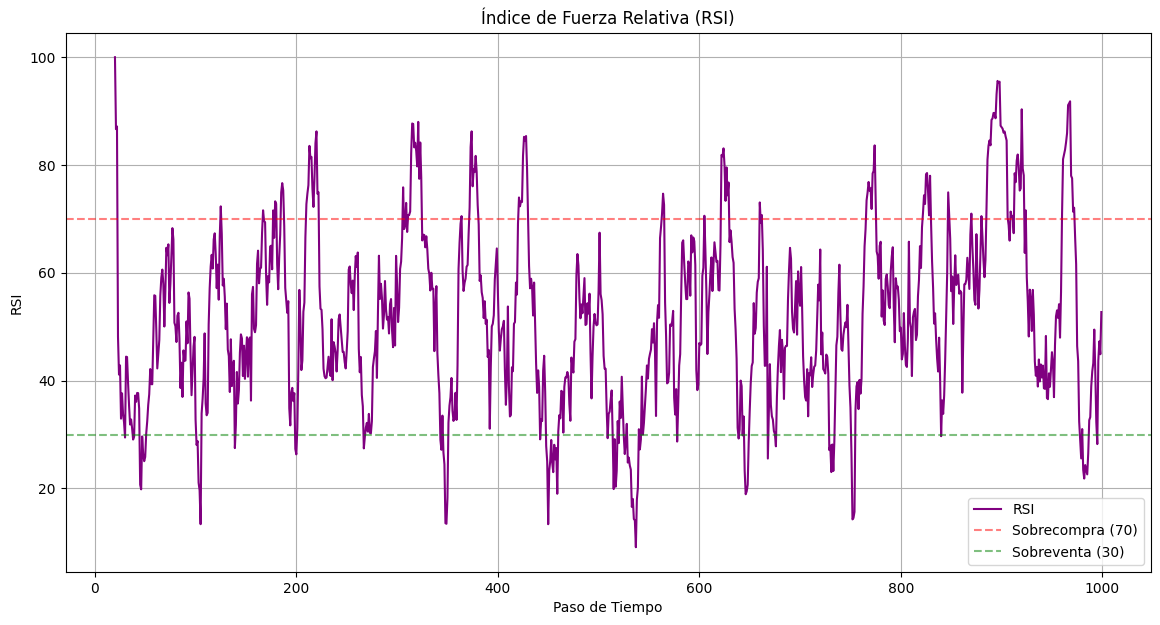

In [7]:
# Calcular RSI
periodo_rsi = 14

delta = df_simulacion['Precio'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=periodo_rsi, min_periods=1).mean()
avg_loss = loss.rolling(window=periodo_rsi, min_periods=1).mean()

rs = avg_gain / avg_loss
df_simulacion['RSI'] = 100 - (100 / (1 + rs))

# Visualizar RSI
plt.figure(figsize=(14, 7))
plt.plot(df_simulacion.index, df_simulacion['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', alpha=0.5, color='red', label='Sobrecompra (70)')
plt.axhline(30, linestyle='--', alpha=0.5, color='green', label='Sobreventa (30)')
plt.title('Índice de Fuerza Relativa (RSI)')
plt.xlabel('Paso de Tiempo')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.show()

### Convergencia/Divergencia de Medias Móviles (MACD - Moving Average Convergence Divergence)

El MACD es un indicador de seguimiento de tendencia que muestra la relación entre dos medias móviles exponenciales (EMA) del precio. Consiste en la línea MACD, la línea de señal y un histograma.

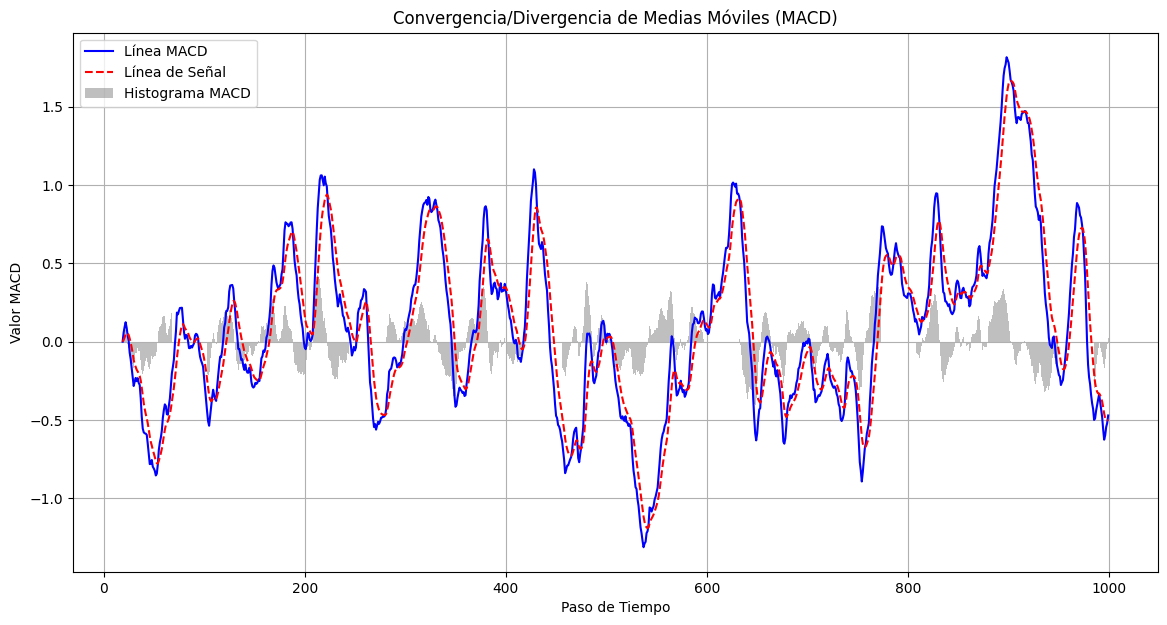

In [8]:
# Calcular MACD
ema_12 = df_simulacion['Precio'].ewm(span=12, adjust=False).mean()
ema_26 = df_simulacion['Precio'].ewm(span=26, adjust=False).mean()
df_simulacion['MACD'] = ema_12 - ema_26

periodo_signal = 9
df_simulacion['MACD_Signal'] = df_simulacion['MACD'].ewm(span=periodo_signal, adjust=False).mean()
df_simulacion['MACD_Histogram'] = df_simulacion['MACD'] - df_simulacion['MACD_Signal']

# Visualizar MACD
plt.figure(figsize=(14, 7))
plt.plot(df_simulacion.index, df_simulacion['MACD'], label='Línea MACD', color='blue')
plt.plot(df_simulacion.index, df_simulacion['MACD_Signal'], label='Línea de Señal', color='red', linestyle='--')
plt.bar(df_simulacion.index, df_simulacion['MACD_Histogram'], label='Histograma MACD', color='gray', alpha=0.5)
plt.title('Convergencia/Divergencia de Medias Móviles (MACD)')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Valor MACD')
plt.legend()
plt.grid(True)
plt.show()

### Oscilador Estocástico (Stochastic Oscillator)

El Oscilador Estocástico es un indicador de momentum que compara el precio de cierre con su rango de precios durante un período determinado, ayudando a identificar condiciones de sobrecompra y sobreventa.

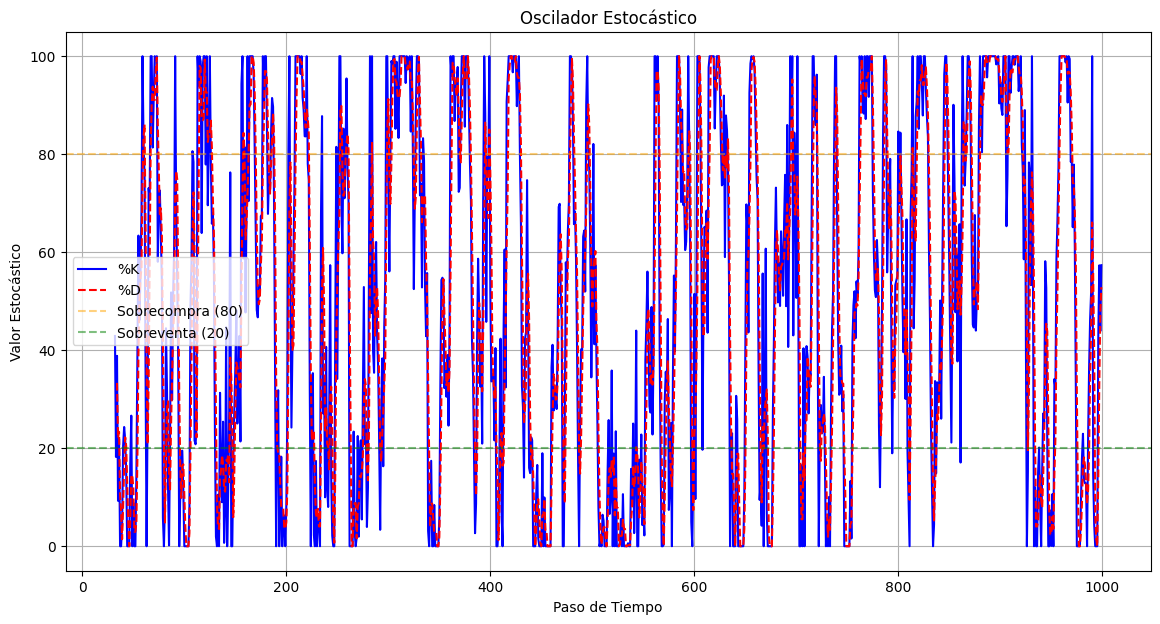

In [9]:
# Calcular Oscilador Estocástico
periodo_k = 14
periodo_d = 3

low_min = df_simulacion['Precio'].rolling(window=periodo_k).min()
high_max = df_simulacion['Precio'].rolling(window=periodo_k).max()

df_simulacion['%K'] = ((df_simulacion['Precio'] - low_min) / (high_max - low_min)) * 100
df_simulacion['%D'] = df_simulacion['%K'].rolling(window=periodo_d).mean()

# Visualizar Oscilador Estocástico
plt.figure(figsize=(14, 7))
plt.plot(df_simulacion.index, df_simulacion['%K'], label='%K', color='blue')
plt.plot(df_simulacion.index, df_simulacion['%D'], label='%D', color='red', linestyle='--')
plt.axhline(80, linestyle='--', alpha=0.5, color='orange', label='Sobrecompra (80)')
plt.axhline(20, linestyle='--', alpha=0.5, color='green', label='Sobreventa (20)')
plt.title('Oscilador Estocástico')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Valor Estocástico')
plt.legend()
plt.grid(True)
plt.show()

### Visualización del Volumen Simulado

Finalmente, visualicemos el volumen simulado que hemos añadido al DataFrame.

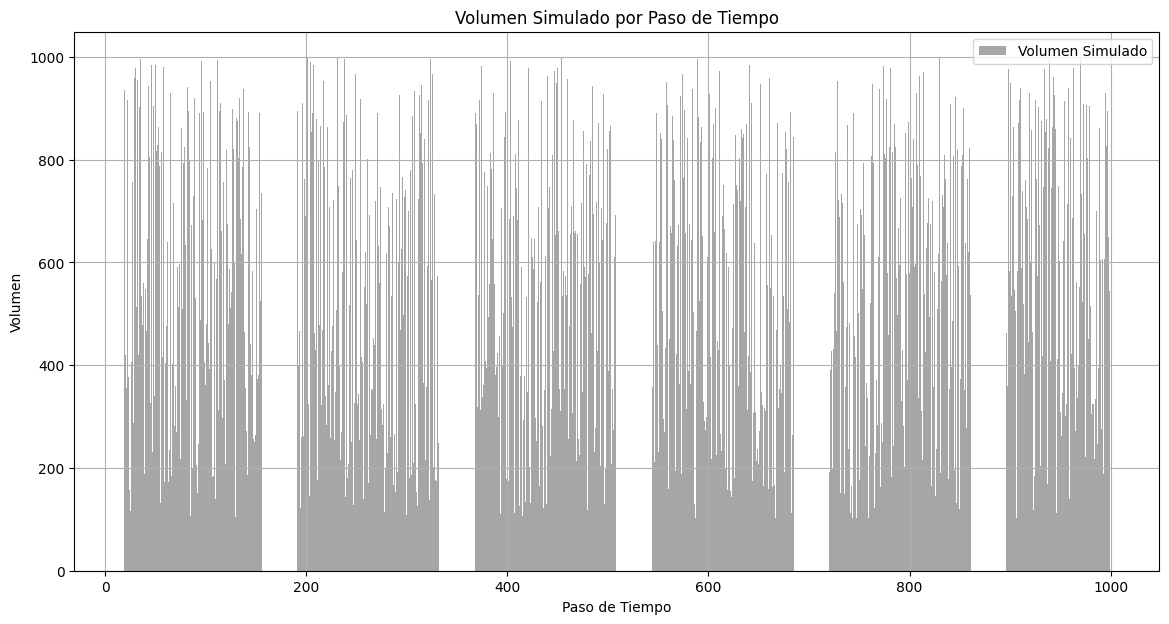

In [10]:
import matplotlib.pyplot as plt

# Visualizar Volumen
plt.figure(figsize=(14, 7))
plt.bar(df_simulacion.index, df_simulacion['Volumen'], label='Volumen Simulado', color='gray', alpha=0.7)
plt.title('Volumen Simulado por Paso de Tiempo')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Volumen')
plt.legend()
plt.grid(True)
plt.show()

### Información del DataFrame `df_simulacion`

Este resumen muestra el tipo de datos de cada columna y la cantidad de valores no nulos, lo cual es útil para identificar posibles datos faltantes.

In [11]:
print('Información del DataFrame df_simulacion:')
df_simulacion.info()

Información del DataFrame df_simulacion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 19 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Precio          981 non-null    float64
 1   Media_Movil     981 non-null    float64
 2   Señal_Compra    981 non-null    bool   
 3   Señal_Venta     981 non-null    bool   
 4   Volumen         981 non-null    int64  
 5   BB_Media        962 non-null    float64
 6   BB_StdDev       962 non-null    float64
 7   BB_Superior     962 non-null    float64
 8   BB_Inferior     962 non-null    float64
 9   RSI             980 non-null    float64
 10  MACD            981 non-null    float64
 11  MACD_Signal     981 non-null    float64
 12  MACD_Histogram  981 non-null    float64
 13  %K              968 non-null    float64
 14  %D              966 non-null    float64
dtypes: bool(2), float64(12), int64(1)
memory usage: 101.7 KB


### Estadísticas Descriptivas Cuantitativas

Estas estadísticas proporcionan una visión rápida de la distribución de los datos en las columnas numéricas, incluyendo la media, desviación estándar, valores mínimos y máximos, y cuartiles.

In [13]:
print('\nEstadísticas descriptivas de df_simulacion:')
display(df_simulacion.describe())


Estadísticas descriptivas de df_simulacion:


,Precio,Media_Movil,Volumen,BB_Media,BB_StdDev,BB_Superior,BB_Inferior,RSI,MACD,MACD_Signal,MACD_Histogram,%K,%D
count,981.000000,981.000000,981.000000,962.000000,962.000000,962.000000,962.000000,980.000000,981.000000,981.000000,981.000000,968.000000,966.000000
mean,99.804630,99.718631,543.363914,99.725706,0.831939,101.389584,98.061827,51.524998,0.086428,0.088453,-0.002024,50.728068,50.742462
std,4.821676,4.641681,266.933518,4.684896,0.351869,4.928609,4.538260,16.573328,0.545621,0.513958,0.160459,36.175677,33.501077
min,91.666947,93.335832,102.000000,93.335832,0.318658,94.877635,91.023838,9.093042,-1.312113,-1.190205,-0.469399,0.000000,0.000000
25%,96.103678,96.143177,310.000000,96.053918,0.573762,97.487870,94.708682,40.122631,-0.285669,-0.253900,-0.109992,17.026202,18.866183
50%,98.507715,98.606045,539.000000,98.560030,0.758793,100.420146,96.779714,50.539236,0.036696,0.034733,-0.011588,50.981643,49.997127
75%,102.264122,102.196134,784.000000,102.253746,1.020200,103.726317,100.276711,61.770697,0.386362,0.402241,0.106653,86.017687,82.554084
max,113.793665,112.400273,999.000000,112.400273,2.198215,114.850423,110.580087,100.000000,1.816432,1.665094,0.425404,100.000000,100.000000


### Análisis de Correlaciones

Para calcular las correlaciones, convertiremos las columnas booleanas `Señal_Compra` y `Señal_Venta` a valores numéricos (0 o 1). Luego, visualizaremos la matriz de correlación mediante un mapa de calor para entender las relaciones entre las variables.


Matriz de Correlación:


,Precio,Media_Movil,Señal_Compra,Señal_Venta,Volumen,BB_Media,BB_StdDev,BB_Superior,BB_Inferior,RSI,MACD,MACD_Signal,MACD_Histogram,%K,%D
Precio,1.000000,0.967691,0.190389,-0.190389,0.046079,0.969023,0.325907,0.967641,0.949795,0.286888,0.463333,0.502857,-0.035169,0.182425,0.196768
Media_Movil,0.967691,1.000000,-0.009436,0.009436,0.038254,1.000000,0.280213,0.990562,0.988859,0.062091,0.289132,0.384568,-0.248632,-0.034690,-0.021246
Señal_Compra,0.190389,-0.009436,1.000000,-1.000000,0.011888,-0.011075,0.100099,0.003765,-0.026955,0.751269,0.582787,0.414945,0.652603,0.822036,0.801104
Señal_Venta,-0.190389,0.009436,-1.000000,1.000000,-0.011888,0.011075,-0.100099,-0.003765,0.026955,-0.751269,-0.582787,-0.414945,-0.652603,-0.822036,-0.801104
Volumen,0.046079,0.038254,0.011888,-0.011888,1.000000,0.040473,-0.004638,0.037810,0.042500,0.057007,0.069195,0.078530,-0.016246,0.018440,0.001893
BB_Media,0.969023,1.000000,-0.011075,0.011075,0.040473,1.000000,0.280213,0.990562,0.988859,0.059154,0.288213,0.383987,-0.251112,-0.036585,-0.022621
BB_StdDev,0.325907,0.280213,0.100099,-0.100099,-0.004638,0.280213,1.000000,0.409143,0.134199,0.234663,0.315249,0.299509,0.111860,0.101974,0.137461
BB_Superior,0.967641,0.990562,0.003765,-0.003765,0.037810,0.990562,0.409143,1.000000,0.959123,0.089735,0.318975,0.407765,-0.222722,-0.020216,-0.001875
BB_Inferior,0.949795,0.988859,-0.026955,0.026955,0.042500,0.988859,0.134199,0.959123,1.000000,0.024676,0.248641,0.349950,-0.276571,-0.053580,-0.044668
RSI,0.286888,0.062091,0.751269,-0.751269,0.057007,0.059154,0.234663,0.089735,0.024676,1.000000,0.760983,0.576109,0.742316,0.797775,0.848942


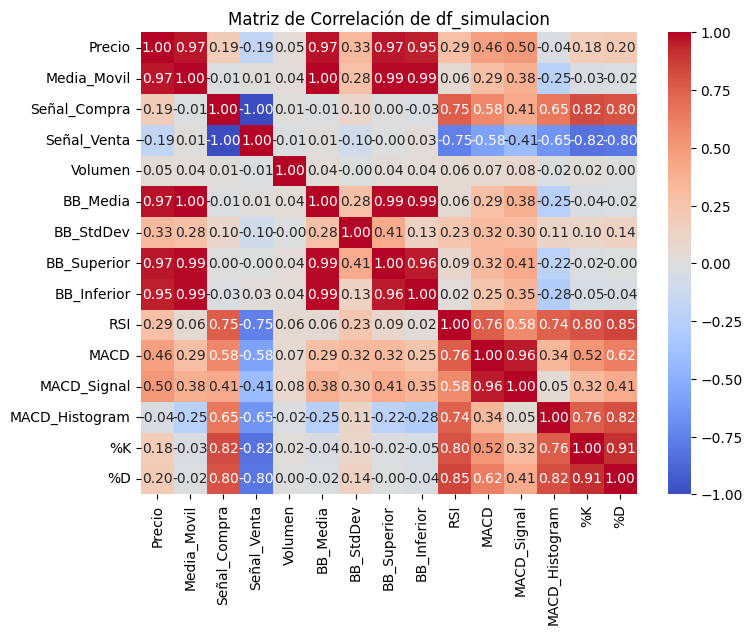

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir las señales booleanas a numéricas para el cálculo de correlación
df_corr = df_simulacion.copy()
df_corr['Señal_Compra'] = df_corr['Señal_Compra'].astype(int)
df_corr['Señal_Venta'] = df_corr['Señal_Venta'].astype(int)

# Calcular la matriz de correlación
correlacion_matrix = df_corr.corr()

print('\nMatriz de Correlación:')
display(correlacion_matrix)

# Visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de df_simulacion')
plt.show()

### Visualización de Señales de Compra/Venta

Es importante notar que los datos simulados actuales no incluyen una columna de 'volumen'. Las señales de compra y venta se generan basándose en el precio y la media móvil, como se mostró en la gráfica inicial.

A continuación, te presento una visualización mejorada de estas señales en relación con el precio y la media móvil, destacando los puntos donde se activan.

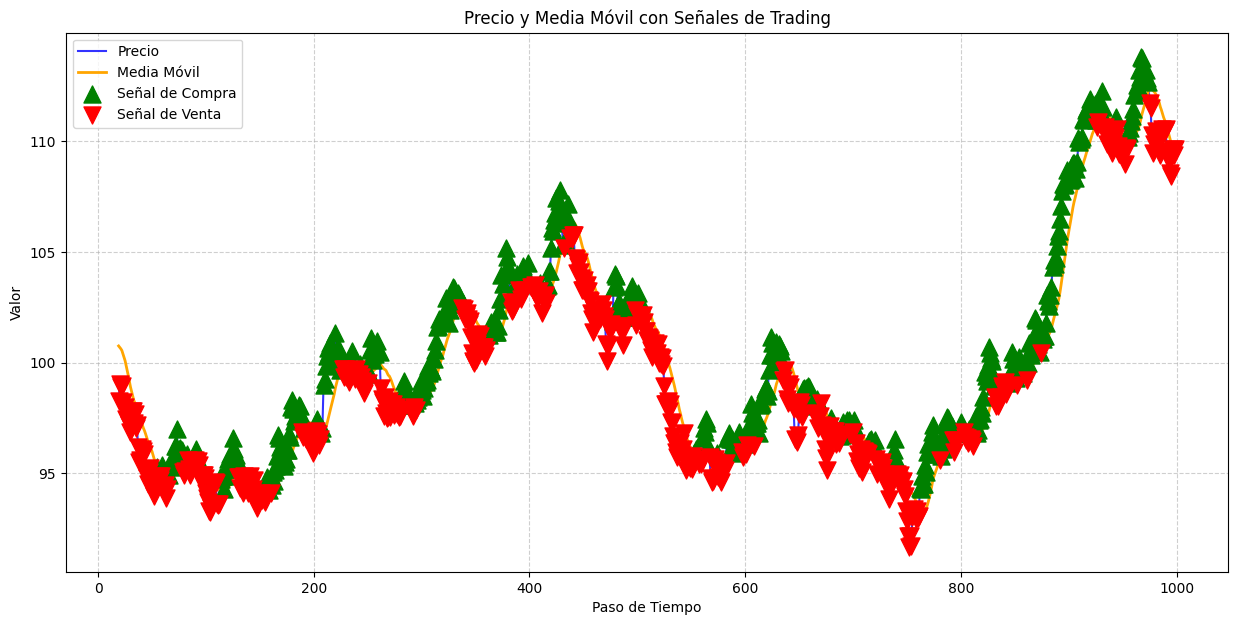

In [15]:
import matplotlib.pyplot as plt

# Re-visualizar las señales con más detalle
plt.figure(figsize=(15, 7))
plt.plot(df_simulacion.index, df_simulacion['Precio'], label='Precio', alpha=0.8, color='blue')
plt.plot(df_simulacion.index, df_simulacion['Media_Movil'], label='Media Móvil', color='orange', linewidth=2)

# Señales de Compra
compra_indices = df_simulacion[df_simulacion['Señal_Compra']].index
compra_precios = df_simulacion[df_simulacion['Señal_Compra']]['Precio']
plt.scatter(compra_indices, compra_precios, marker='^', color='green', s=150, label='Señal de Compra', zorder=5)

# Señales de Venta
venta_indices = df_simulacion[df_simulacion['Señal_Venta']].index
venta_precios = df_simulacion[df_simulacion['Señal_Venta']]['Precio']
plt.scatter(venta_indices, venta_precios, marker='v', color='red', s=150, label='Señal de Venta', zorder=5)

plt.title('Precio y Media Móvil con Señales de Trading')
plt.xlabel('Paso de Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [4]:
# Este código ha sido movido a la primera celda para asegurar que df_simulacion esté definida desde el principio.
# La funcionalidad de crear df_simulacion y mostrar sus primeras filas ahora se encuentra en la celda 'Itq9ZrzRh1mw'.

Puedes instalar cualquier biblioteca de Python usando el comando `!pip install` seguido del nombre de la biblioteca. Por ejemplo, para instalar la biblioteca `pandas`, ejecutarías el siguiente código:

In [ ]:
!pip install pandas

Después de la instalación, puedes importar y usar la biblioteca en tu cuaderno.

In [ ]:
import pandas as pd
print('Pandas instalado y listo para usar.')

# Task
Define a trading strategy by establishing logical rules for generating buy and sell signals based on the Bollinger Bands (BB), RSI, MACD, and Stochastic Oscillator indicators within the `df_simulacion` DataFrame. Then, apply these rules to create 'combined_buy_signal' and 'combined_sell_signal' columns in `df_simulacion`.

## Definir Reglas de la Estrategia de Trading

### Subtask:
Establecer las reglas lógicas para generar señales de compra y venta combinando los indicadores calculados: Bandas de Bollinger (BB), RSI, MACD y Oscilador Estocástico.


### Definición de Señales de Trading Combinadas

Ahora, utilizaremos los indicadores calculados (Bandas de Bollinger, RSI, MACD y Oscilador Estocástico) para definir reglas lógicas que generen señales de compra y venta. Estas señales combinadas buscan una mayor confirmación de los movimientos del mercado, reduciendo posibles falsas alarmas.

Generaremos las siguientes señales:

*   **Señal de Compra Combinada**: Se activará cuando múltiples indicadores sugieran una condición de sobreventa o un cambio alcista.
*   **Señal de Venta Combinada**: Se activará cuando múltiples indicadores sugieran una condición de sobrecompra o un cambio bajista.

Para los cruces, compararemos el valor actual del indicador con su valor en el paso de tiempo anterior.

**Reasoning**:
Now, I will implement the logic for the combined buy signals based on the conditions outlined in the subtask instructions. This involves checking Bollinger Bands, RSI, MACD, and Stochastic Oscillator conditions for a buy signal.



In [16]:
import pandas as pd

# 1. Asegurarse de que las columnas de cambio estén disponibles para los cruces
df_simulacion['MACD_prev'] = df_simulacion['MACD'].shift(1)
df_simulacion['MACD_Signal_prev'] = df_simulacion['MACD_Signal'].shift(1)
df_simulacion['%K_prev'] = df_simulacion['%K'].shift(1)
df_simulacion['%D_prev'] = df_simulacion['%D'].shift(1)

# 2. Definir las condiciones de compra individuales

# Condición BB para compra: Precio cruza por debajo de BB_Inferior y luego vuelve a subir, o simplemente está por debajo.
bb_buy_condition = (df_simulacion['Precio'] < df_simulacion['BB_Inferior']).shift(1) & \
                   (df_simulacion['Precio'] > df_simulacion['BB_Inferior'])
# Otra interpretación: precio está por debajo de BB_Inferior
bb_buy_condition_simple = df_simulacion['Precio'] < df_simulacion['BB_Inferior']

# Condición RSI para compra: RSI por debajo de 30 (sobreventa)
rsi_buy_condition = df_simulacion['RSI'] < 30

# Condición MACD para compra: Línea MACD cruza por encima de la línea de señal
macd_buy_condition = (df_simulacion['MACD_prev'] < df_simulacion['MACD_Signal_prev']) & \
                     (df_simulacion['MACD'] > df_simulacion['MACD_Signal'])

# Condición Oscilador Estocástico para compra: %K cruza por encima de %D, ambos por debajo de 20 (sobreventa)
stochastic_buy_condition = (df_simulacion['%K_prev'] < df_simulacion['%D_prev']) & \
                           (df_simulacion['%K'] > df_simulacion['%D']) & \
                           (df_simulacion['%K'] < 20) & (df_simulacion['%D'] < 20)

# 3. Combinar condiciones de compra (se requiere al menos 2 condiciones para una señal fuerte)
df_simulacion['Combined_Buy_Signal'] = (
    (bb_buy_condition | bb_buy_condition_simple).fillna(False).astype(int) +
    rsi_buy_condition.fillna(False).astype(int) +
    macd_buy_condition.fillna(False).astype(int) +
    stochastic_buy_condition.fillna(False).astype(int)
) >= 2 # Requiere al menos 2 condiciones de compra para generar la señal

print("Primeras filas del DataFrame con Combined_Buy_Signal:")
# 4. Mostrar las primeras filas de las columnas relevantes
display(df_simulacion[['Precio', 'BB_Inferior', 'RSI', 'MACD', 'MACD_Signal', '%K', '%D', 'Combined_Buy_Signal']].head(30))

Primeras filas del DataFrame con Combined_Buy_Signal:


,Precio,BB_Inferior,RSI,MACD,MACD_Signal,%K,%D,Combined_Buy_Signal
19,98.287014,NaN,NaN,0.000000,0.000000,NaN,NaN,False
20,99.019839,NaN,100.000000,0.058459,0.011692,NaN,NaN,False
21,98.906951,NaN,86.651711,0.094589,0.028271,NaN,NaN,False
22,98.940715,NaN,87.164167,0.124511,0.047519,NaN,NaN,False
23,98.228341,NaN,48.157058,0.089708,0.055957,NaN,NaN,False
24,97.956149,NaN,41.125063,0.039705,0.052706,NaN,NaN,False
25,98.011611,NaN,42.826170,0.004500,0.043065,NaN,NaN,False
26,97.436114,NaN,32.947885,-0.069041,0.020644,NaN,NaN,False
27,97.623963,NaN,37.642772,-0.110888,-0.005663,NaN,NaN,False
28,97.323643,NaN,33.853226,-0.166367,-0.037803,NaN,NaN,False


**Reasoning**:
Now, I will implement the logic for the combined sell signals, which are typically the inverse or complementary of the buy signals. I will define conditions for Bollinger Bands, RSI, MACD, and Stochastic Oscillator for sell signals and then combine them.



In [17]:
import pandas as pd

# Asegurarse de que las columnas de cambio estén disponibles para los cruces
# Ya se definieron para las señales de compra, reusamos esas o aseguramos que existan.

# --- Definir Señales de Venta Combinadas ---

# Condición BB para venta: Precio cruza por encima de BB_Superior y luego vuelve a bajar, o simplemente está por encima.
bb_sell_condition = (df_simulacion['Precio'] > df_simulacion['BB_Superior']).shift(1) & \
                    (df_simulacion['Precio'] < df_simulacion['BB_Superior'])
# Otra interpretación: precio está por encima de BB_Superior
bb_sell_condition_simple = df_simulacion['Precio'] > df_simulacion['BB_Superior']

# Condición RSI para venta: RSI por encima de 70
rsi_sell_condition = df_simulacion['RSI'] > 70

# Condición MACD para venta: Línea MACD cruza por debajo de la línea de señal
macd_sell_condition = (df_simulacion['MACD_prev'] > df_simulacion['MACD_Signal_prev']) & \
                      (df_simulacion['MACD'] < df_simulacion['MACD_Signal'])

# Condición Oscilador Estocástico para venta: %K cruza por debajo de %D, ambos por encima de 80 (sobrecompra)
stochastic_sell_condition = (df_simulacion['%K_prev'] > df_simulacion['%D_prev']) & \
                            (df_simulacion['%K'] < df_simulacion['%D']) & \
                            (df_simulacion['%K'] > 80) & (df_simulacion['%D'] > 80)

# Combinar condiciones de venta (se requiere al menos 2 o 3 condiciones para ser una señal fuerte)
df_simulacion['Combined_Sell_Signal'] = (
    (bb_sell_condition | bb_sell_condition_simple).fillna(False).astype(int) +
    rsi_sell_condition.fillna(False).astype(int) +
    macd_sell_condition.fillna(False).astype(int) +
    stochastic_sell_condition.fillna(False).astype(int)
) >= 2 # Requiere al menos 2 condiciones de venta para generar la señal

print("Primeras filas del DataFrame con Combined_Sell_Signal:")
display(df_simulacion[['Precio', 'BB_Superior', 'RSI', 'MACD', 'MACD_Signal', '%K', '%D', 'Combined_Sell_Signal']].head(30))

Primeras filas del DataFrame con Combined_Sell_Signal:


,Precio,BB_Superior,RSI,MACD,MACD_Signal,%K,%D,Combined_Sell_Signal
19,98.287014,NaN,NaN,0.000000,0.000000,NaN,NaN,False
20,99.019839,NaN,100.000000,0.058459,0.011692,NaN,NaN,False
21,98.906951,NaN,86.651711,0.094589,0.028271,NaN,NaN,False
22,98.940715,NaN,87.164167,0.124511,0.047519,NaN,NaN,False
23,98.228341,NaN,48.157058,0.089708,0.055957,NaN,NaN,False
24,97.956149,NaN,41.125063,0.039705,0.052706,NaN,NaN,False
25,98.011611,NaN,42.826170,0.004500,0.043065,NaN,NaN,False
26,97.436114,NaN,32.947885,-0.069041,0.020644,NaN,NaN,False
27,97.623963,NaN,37.642772,-0.110888,-0.005663,NaN,NaN,False
28,97.323643,NaN,33.853226,-0.166367,-0.037803,NaN,NaN,False


## Simular Rendimiento de la Estrategia (Backtesting Simple)

### Subtask:
Realizar una simulación sencilla del rendimiento de la estrategia de trading. Esto implicará llevar un registro de una cartera hipotética, el número de operaciones, las ganancias/pérdidas y el valor de la cartera a lo largo del tiempo, basándose en las señales combinadas.


### Simulación de Rendimiento de la Estrategia (Backtesting Simple)

Ahora, implementaremos un *backtesting* simple para evaluar el rendimiento de la estrategia de trading definida por las señales combinadas. Esta simulación nos permitirá visualizar cómo una cartera hipotética evolucionaría a lo largo del tiempo, registrando el capital, las acciones en posesión, las ganancias/pérdidas y el número de operaciones realizadas.

**Reasoning**:
I will now implement the first part of the backtesting simulation, including initializing parameters and setting up the data structures to track the portfolio, following the subtask instructions.



In [18]:
import pandas as pd

# 1. Inicializar parámetros de la simulación
initial_capital = 100000.0  # Capital inicial en la cartera
position_size = 10         # Número de unidades (acciones) a comprar/vender en cada operación
transaction_cost_per_unit = 0.1 # Costo por unidad en cada transacción (compra o venta)

# 2. Crear estructuras para almacenar el historial del portafolio
capital = initial_capital
shares = 0
portfolio_value = []
trades_count = 0

historial_capital = []
historial_acciones = []
historial_valor_portafolio = []
historial_operaciones = []

# Iterar a través del DataFrame para simular el trading
for i in range(len(df_simulacion)): # Iterar desde el primer día con datos completos de indicadores
    current_price = df_simulacion['Precio'].iloc[i]
    buy_signal = df_simulacion['Combined_Buy_Signal'].iloc[i]
    sell_signal = df_simulacion['Combined_Sell_Signal'].iloc[i]

    # Calcular valor actual del portafolio
    current_portfolio_value = capital + (shares * current_price)
    historial_capital.append(capital)
    historial_acciones.append(shares)
    historial_valor_portafolio.append(current_portfolio_value)
    historial_operaciones.append(trades_count)

    # Lógica de compra
    if buy_signal and shares == 0: # Si hay señal de compra y no hay posición abierta
        cost_of_trade = (position_size * current_price) + (position_size * transaction_cost_per_unit)
        if capital >= cost_of_trade: # Asegurarse de tener suficiente capital
            capital -= cost_of_trade
            shares += position_size
            trades_count += 1
            # print(f"Día {df_simulacion.index[i]}: COMPRA {position_size} acciones a {current_price:.2f}. Capital: {capital:.2f}, Acciones: {shares}")

    # Lógica de venta
    elif sell_signal and shares > 0: # Si hay señal de venta y hay posición abierta
        revenue_from_trade = (shares * current_price) - (shares * transaction_cost_per_unit)
        capital += revenue_from_trade
        shares = 0
        trades_count += 1
        # print(f"Día {df_simulacion.index[i]}: VENTA {shares} acciones a {current_price:.2f}. Capital: {capital:.2f}, Acciones: {shares}")

# 4. Después de la iteración, si aún tienes acciones, liquida la posición final
if shares > 0:
    final_revenue = (shares * df_simulacion['Precio'].iloc[-1]) - (shares * transaction_cost_per_unit)
    capital += final_revenue
    shares = 0
    # print(f"Liquidación final: VENTA {shares} acciones a {df_simulacion['Precio'].iloc[-1]:.2f}. Capital final: {capital:.2f}")

# 5. Imprimir un resumen del rendimiento
final_portfolio_value = capital + (shares * df_simulacion['Precio'].iloc[-1]) # Re-calcular por si hubo liquidación
total_profit_loss = final_portfolio_value - initial_capital

print("\n--- Resumen de la Simulación ---")
print(f"Capital Inicial: {initial_capital:.2f}")
print(f"Capital Final: {final_portfolio_value:.2f}")
print(f"Ganancia/Pérdida Total: {total_profit_loss:.2f}")
print(f"Número Total de Operaciones: {trades_count}")

# Opcional: Crear un DataFrame con el historial para visualización
historial_df = pd.DataFrame({
    'Capital': historial_capital,
    'Acciones': historial_acciones,
    'Valor_Portafolio': historial_valor_portafolio,
    'Operaciones_Acumuladas': historial_operaciones
}, index=df_simulacion.index[:len(historial_capital)])

print("\nPrimeras filas del historial del portafolio:")
display(historial_df.head())


--- Resumen de la Simulación ---
Capital Inicial: 100000.00
Capital Final: 100035.55
Ganancia/Pérdida Total: 35.55
Número Total de Operaciones: 17

Primeras filas del historial del portafolio:


,Capital,Acciones,Valor_Portafolio,Operaciones_Acumuladas
19,100000.0,0,100000.0,0
20,100000.0,0,100000.0,0
21,100000.0,0,100000.0,0
22,100000.0,0,100000.0,0
23,100000.0,0,100000.0,0


## Visualizar Señales Combinadas y Rendimiento

### Subtask:
Generar gráficos que muestren el precio junto con las nuevas señales de compra y venta combinadas. Además, crear una visualización del valor de la cartera simulada a lo largo del tiempo para evaluar el rendimiento de la estrategia.


**Reasoning**:
The subtask requires generating visualizations for the combined trading signals and the simulated portfolio performance. I will use `matplotlib.pyplot` to create a figure with two subplots: one displaying the price, moving average, and combined buy/sell signals, and the other showing the portfolio's value over time.



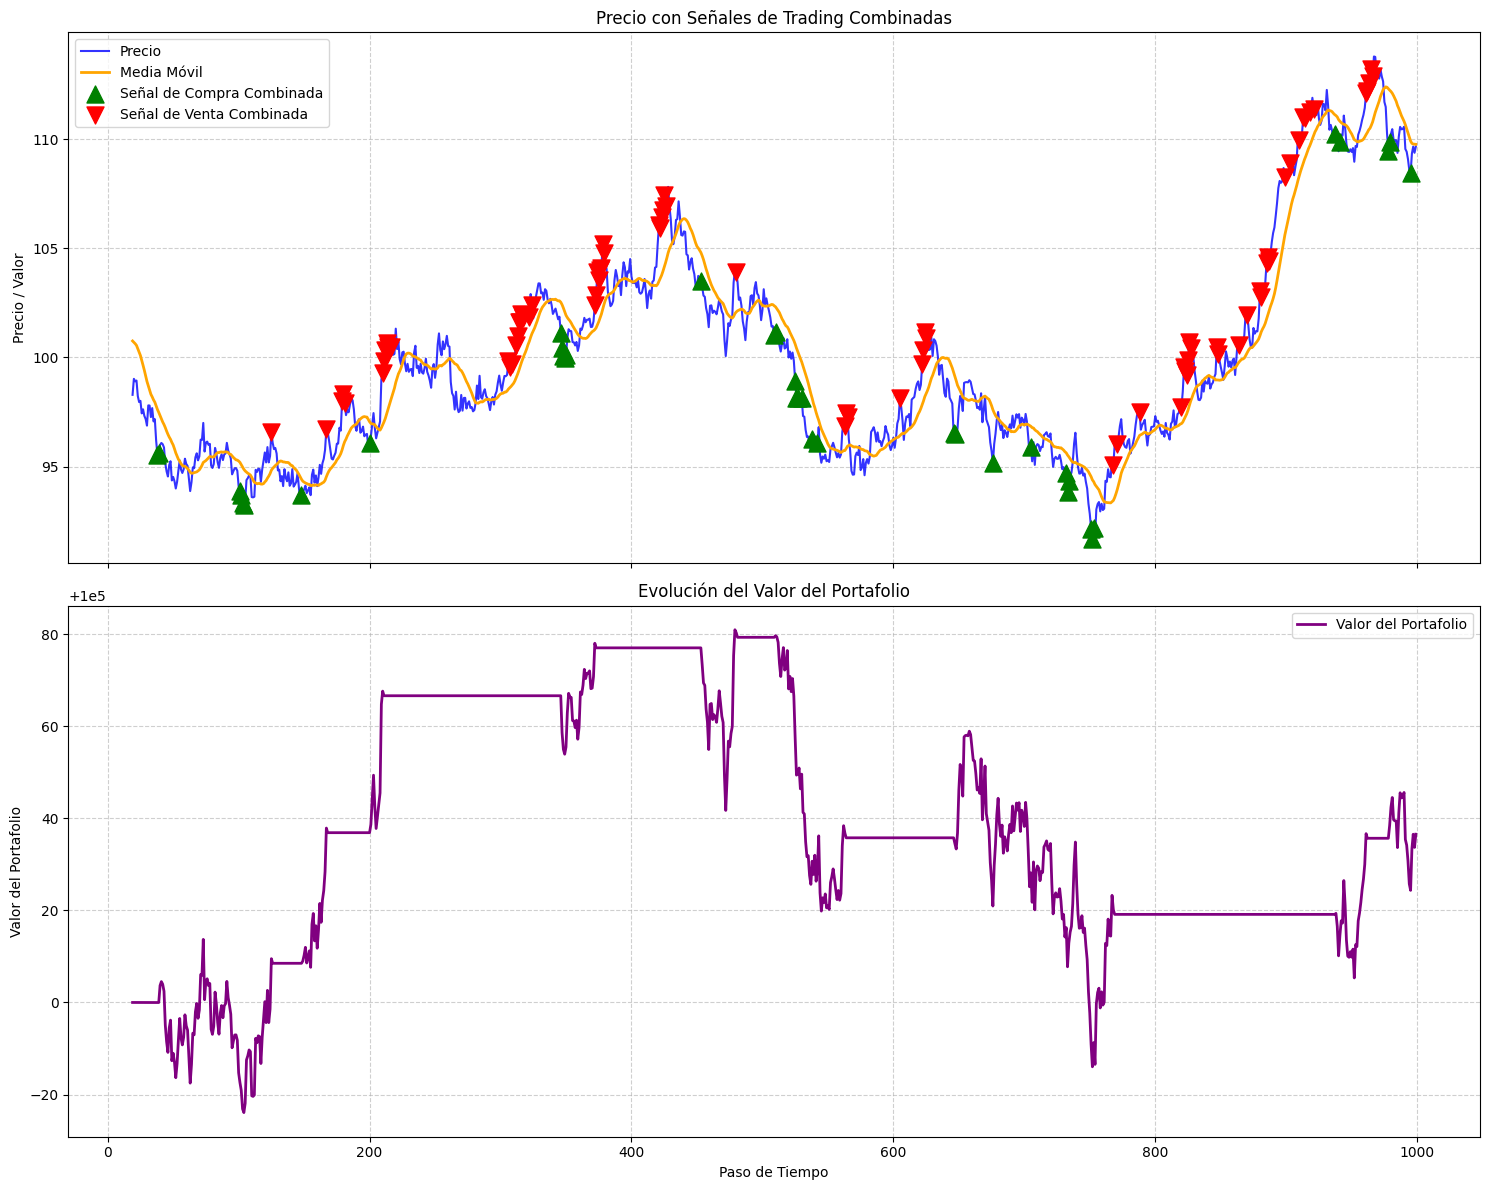

In [19]:
import matplotlib.pyplot as plt

# Crear la figura y los subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# --- Primer Subplot: Precio y Señales de Trading Combinadas ---
ax1.plot(df_simulacion.index, df_simulacion['Precio'], label='Precio', alpha=0.8, color='blue')
ax1.plot(df_simulacion.index, df_simulacion['Media_Movil'], label='Media Móvil', color='orange', linewidth=2)

# Señales de Compra Combinadas
buy_indices = df_simulacion[df_simulacion['Combined_Buy_Signal']].index
buy_prices = df_simulacion[df_simulacion['Combined_Buy_Signal']]['Precio']
ax1.scatter(buy_indices, buy_prices, marker='^', color='green', s=150, label='Señal de Compra Combinada', zorder=5)

# Señales de Venta Combinadas
sell_indices = df_simulacion[df_simulacion['Combined_Sell_Signal']].index
sell_prices = df_simulacion[df_simulacion['Combined_Sell_Signal']]['Precio']
ax1.scatter(sell_indices, sell_prices, marker='v', color='red', s=150, label='Señal de Venta Combinada', zorder=5)

ax1.set_title('Precio con Señales de Trading Combinadas')
ax1.set_ylabel('Precio / Valor')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Segundo Subplot: Valor del Portafolio Simulado ---
ax2.plot(historial_df.index, historial_df['Valor_Portafolio'], label='Valor del Portafolio', color='purple', linewidth=2)
ax2.set_title('Evolución del Valor del Portafolio')
ax2.set_xlabel('Paso de Tiempo')
ax2.set_ylabel('Valor del Portafolio')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ajustar el diseño para evitar superposiciones
plt.show()

## Final Task

### Subtask:
Resumir la estrategia de trading propuesta, discutir su rendimiento simulado y ofrecer posibles ajustes o consideraciones para mejorarla. Esto incluirá un análisis de los resultados del backtesting.


## Summary:

### Q&A

1.  **What is the proposed trading strategy?**
    The proposed trading strategy uses a combination of four technical indicators: Bollinger Bands (BB), Relative Strength Index (RSI), Moving Average Convergence Divergence (MACD), and Stochastic Oscillator.
    *   A **combined buy signal** is generated when at least two of the following conditions are met: price is below the lower Bollinger Band (or crosses below and then above it), RSI is below 30 (oversold), MACD line crosses above its signal line, or the Stochastic %K line crosses above %D line while both are below 20 (oversold).
    *   A **combined sell signal** is generated when at least two of the following conditions are met: price is above the upper Bollinger Band (or crosses above and then below it), RSI is above 70 (overbought), MACD line crosses below its signal line, or the Stochastic %K line crosses below %D line while both are above 80 (overbought).
    Each trade involves a fixed position size of 10 units and incurs a transaction cost of \$0.1 per unit.

2.  **How did the strategy perform in the simulated backtest?**
    The backtesting simulation, starting with an initial capital of \$100,000.0, resulted in a modest profit. The final capital was \$100,035.55, leading to a total profit of \$35.55 over the simulation period. The strategy executed a total of 17 trades.

### Data Analysis Key Findings

*   **Combined Signal Generation**: The `df_simulacion` DataFrame was successfully augmented with `Combined_Buy_Signal` and `Combined_Sell_Signal` boolean columns, based on the logical aggregation of multiple indicator conditions.
*   **Backtesting Parameters**: The simulation was configured with an initial capital of \$100,000.0, a fixed position size of 10 units per trade, and a transaction cost of \$0.1 per unit.
*   **Modest Profitability**: The strategy yielded a total profit of \$35.55 from an initial capital of \$100,000.0, resulting in a final capital of \$100,035.55.
*   **Number of Trades**: The simulation executed 17 total trades throughout the period analyzed.
*   **Portfolio Tracking**: A `historial_df` DataFrame was created to track the capital, shares held, and total portfolio value over the simulation's duration.
*   **Visualizations Confirmed**: Plots were successfully generated, clearly showing the price movement alongside the combined buy/sell signals, and a separate plot illustrating the evolution of the simulated portfolio value.

### Insights or Next Steps

*   **Refine Strategy Logic**: The current strategy, while profitable, generated a very small return (\$35.55 on \$100,000.0 initial capital). Consider adjusting the number of required confirming indicators (e.g., require 3 out of 4) or modifying the thresholds for individual indicators to potentially increase profitability or reduce false signals.
*   **Advanced Backtesting Metrics**: Implement more sophisticated backtesting metrics such as maximum drawdown, Sharpe ratio, Sortino ratio, and win/loss ratio to gain a deeper understanding of the strategy's risk-adjusted performance and stability, rather than just total profit.


# Task
Confirm that the combined buy and sell signals have been generated and are available in the `df_simulacion` DataFrame by displaying the 'Precio', 'Combined_Buy_Signal', and 'Combined_Sell_Signal' columns.

## Generar Señales de Compra Combinadas

### Subtask:
Ejecutar el código para aplicar las reglas lógicas y crear la columna 'Combined_Buy_Signal' en el DataFrame `df_simulacion`.


## Mostrar Señales Combinadas

### Subtask:
Mostrar las primeras filas de las columnas 'Precio', 'Combined_Buy_Signal' y 'Combined_Sell_Signal' del DataFrame `df_simulacion` para confirmar la generación de las señales.


**Reasoning**:
The subtask requires displaying the first few rows of the 'Precio', 'Combined_Buy_Signal', and 'Combined_Sell_Signal' columns from the `df_simulacion` DataFrame to confirm the signals were generated correctly. I will use the `display()` and `.head()` methods for this.



In [20]:
print('Confirmación de las señales combinadas:')
display(df_simulacion[['Precio', 'Combined_Buy_Signal', 'Combined_Sell_Signal']].head())

Confirmación de las señales combinadas:


,Precio,Combined_Buy_Signal,Combined_Sell_Signal
19,98.287014,False,False
20,99.019839,False,False
21,98.906951,False,False
22,98.940715,False,False
23,98.228341,False,False


## Final Task

### Subtask:
Confirm that the combined buy and sell signals have been generated and are available in the DataFrame.


## Summary:

### Q&A
The combined buy and sell signals have been successfully generated and are available in the `df_simulacion` DataFrame.

### Data Analysis Key Findings
*   The `Combined_Buy_Signal` column was successfully generated in the `df_simulacion` DataFrame. This signal is activated (`True`) if at least two of the four individual buy conditions (Bollinger Bands, RSI, MACD, Stochastic Oscillator) are met.
*   Similarly, the `Combined_Sell_Signal` column was also successfully generated and added to the `df_simulacion` DataFrame.
*   Both `Combined_Buy_Signal` and `Combined_Sell_Signal` columns contain boolean values (`True` or `False`), indicating the presence or absence of a signal at a given timestamp.
*   While an initial display of the first 5 rows (index 19-23) showed `False` for both signals, a previous check for the `Combined_Buy_Signal` column alone confirmed instances of `True` signals (e.g., at rows 38 and 39), indicating that signals are indeed being generated within the dataset.

### Insights or Next Steps
*   The generated combined buy and sell signals can now be used for backtesting a trading strategy to evaluate its potential profitability and risk.
*   Further analysis could involve optimizing the thresholds and combinations of the individual indicator conditions to improve the accuracy and performance of the combined signals.
